In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load the data
prices = pd.read_csv('../data/raw/electricity_prices.csv')
generation = pd.read_csv('../data/raw/generation_by_source.csv')

#sanity check
print(prices.shape)
print(prices.dtypes)
print(prices.head())

Matplotlib is building the font cache; this may take a moment.


(4545, 10)
stateid                 str
statedescription        str
sectorid                str
sectorname              str
price               float64
sales               float64
price-units             str
sales-units             str
year                  int64
month                 int64
dtype: object
  stateid statedescription sectorid   sectorname  price       sales  \
0      CA       California      COM   commercial  28.18  7809.09440   
1      CA       California      IND   industrial  20.06  3299.71962   
2      CA       California      RES  residential  33.35  6728.31442   
3      CO         Colorado      COM   commercial  13.01  1804.37089   
4      CO         Colorado      IND   industrial   9.77  1255.39261   

               price-units             sales-units  year  month  
0  cents per kilowatt-hour  million kilowatt hours  2026      3  
1  cents per kilowatt-hour  million kilowatt hours  2026      3  
2  cents per kilowatt-hour  million kilowatt hours  2026      3  
3  c

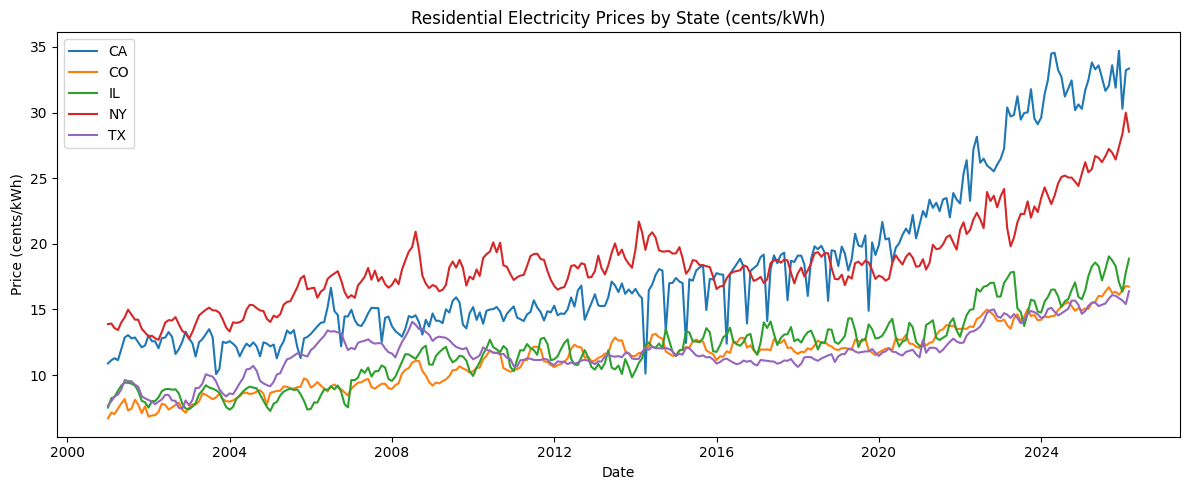

In [2]:
#create a date column for time series plotting
prices['date'] = pd.to_datetime(prices[['year', 'month']].assign(day=1))

#filter to residential only
res = prices[prices['sectorid'] == 'RES']

#plot price over time by state
plt.figure(figsize=(12, 5))
for state in res['stateid'].unique():
    subset = res[res['stateid'] == state].sort_values('date')
    plt.plot(subset['date'], subset['price'], label=state)

plt.title('Residential Electricity Prices by State (cents/kWh)')
plt.xlabel('Date')
plt.ylabel('Price (cents/kWh)')
plt.legend()
plt.tight_layout()
plt.show()

CA and NY are expensive and accelerating sharply post-2020. Policy, infrastructure, and grid mix all playing a role

CO, TX, IL are cheaper and much flatter. Makes sense as fossil fuel heavy grids tend to be more stable

TX has a visible spike around 2014, likely the polar vortex event, exactly the kind of volatility we want to predict

Post-2020 surge across all states. Possibly because of inflation + energy transition costs

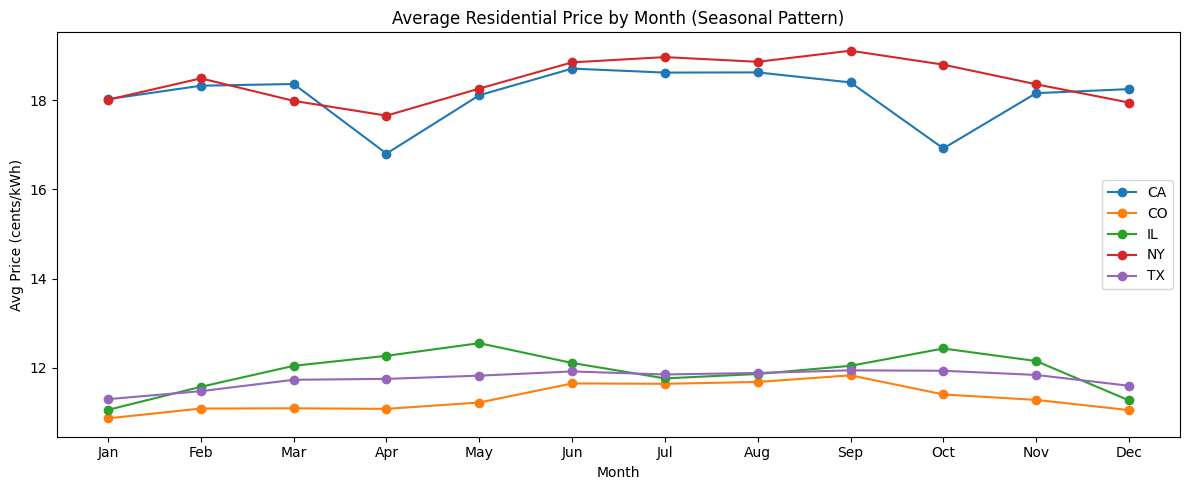

In [3]:
#average price by month across all years (seasonality)
res['month_name'] = pd.to_datetime(res['month'], format='%m').dt.strftime('%b')

seasonal = res.groupby(['stateid', 'month'])['price'].mean().reset_index()

plt.figure(figsize=(12, 5))
for state in seasonal['stateid'].unique():
    subset = seasonal[seasonal['stateid'] == state]
    plt.plot(subset['month'], subset['price'], marker='o', label=state)

plt.title('Average Residential Price by Month (Seasonal Pattern)')
plt.xlabel('Month')
plt.ylabel('Avg Price (cents/kWh)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.tight_layout()
plt.show()

CA and NY peak in summer (Jun/Jul. Air conditioning demand drives prices up

CA dips in April/October. Seasons with mild weather and strong solar output

CO, TX, IL are very flat. Cheaper, more fossil-fuel-stable grids absorb demand swings better

IL spikes in May. Interesting, worth investigating later, could be a data mistake or grid constraint

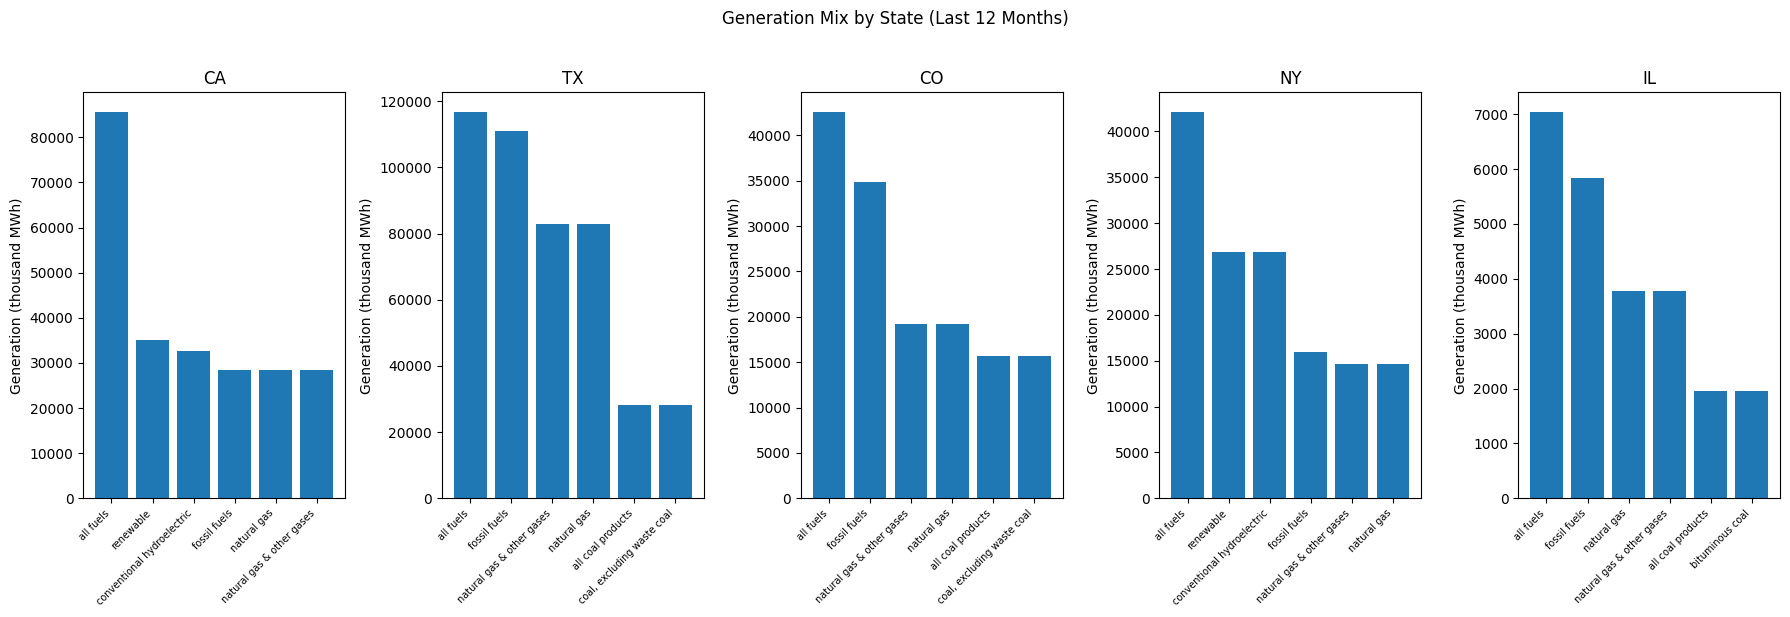

In [4]:
#look at generation mix for each state
gen = generation.copy()
gen['date'] = pd.to_datetime(gen[['year', 'month']].assign(day=1))

#filter to most recent 12 months
recent = gen[gen['date'] >= '2025-01-01']

#total generation by state and fuel type
mix = recent.groupby(['location', 'fueltypedescription'])['generation'].sum().reset_index()

#plot
fig, axes = plt.subplots(1, 5, figsize=(18, 6))
states = ['CA', 'TX', 'CO', 'NY', 'IL']

for ax, state in zip(axes, states):
    subset = mix[mix['location'] == state].sort_values('generation', ascending=False)
    subset = subset[subset['generation'] > 0].head(6)  # top 6 fuel types
    ax.bar(range(len(subset)), subset['generation'])
    ax.set_xticks(range(len(subset)))
    ax.set_xticklabels(subset['fueltypedescription'], rotation=45, ha='right', fontsize=7)
    ax.set_title(state)
    ax.set_ylabel('Generation (thousand MWh)')

plt.suptitle('Generation Mix by State (Last 12 Months)', y=1.02)
plt.tight_layout()
plt.show()

CA: Heavily diversified clean grid. Renewables (~35k MWh) and conventional hydroelectric (~33k) are the two biggest sources after the "all fuels" aggregate. Fossil fuels and natural gas are present but notably smaller. CA generates roughly 40% renewable/hydro.

TX: Almost entirely fossil fuels. The "fossil fuels" bar is nearly as tall as "all fuels" (~110k vs ~115k), meaning almost nothing is renewable in this snapshot. Natural gas dominates (~82k), with coal a distant second (~27k). TX is a gas grid.

CO: Similar fossil-heavy profile to TX but much smaller grid (~43k total). Fossil fuels account for ~35k of that. Natural gas and coal are roughly even contributors (~19k and ~16k respectively). Very little renewable visible in the top 6.

NY: Interesting split. Renewables (~27k) and conventional hydro (~27k) are nearly equal, together making up over half the grid. Fossil fuels are present but clearly secondary (~16k). NY looks the most balanced of the five.

IL: Important caveat: IL's y-axis only goes to ~7k, far smaller than the others. Of what's shown, fossil fuels dominate with natural gas and coal roughly split. 

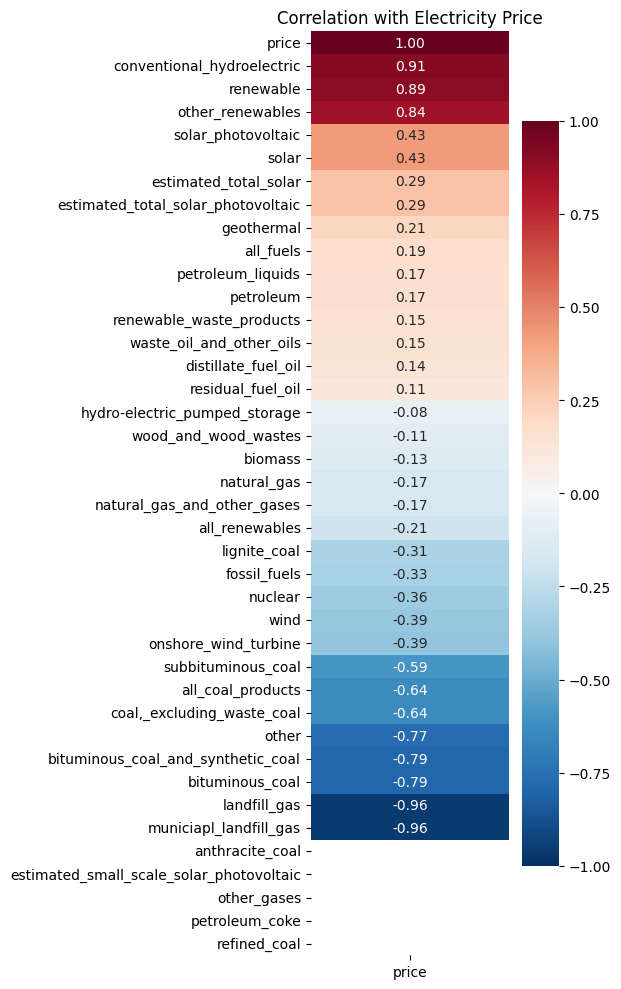

In [5]:
#merge prices and generation to see correlation
#first pivot generation wide. One column per fuel type
gen_pivot = generation[generation['year'] >= 2015].copy()
gen_pivot = gen_pivot.groupby(['location', 'year', 'month', 'fueltypedescription'])['generation'].sum().reset_index()
gen_pivot = gen_pivot.pivot_table(index=['location', 'year', 'month'],
                                   columns='fueltypedescription',
                                   values='generation').reset_index()

#clean column names
gen_pivot.columns.name = None
gen_pivot.columns = [c.lower().replace(' ', '_').replace('&', 'and') for c in gen_pivot.columns]

#merge with residential prices
res_clean = res[['stateid', 'year', 'month', 'price']].copy()
merged = res_clean.merge(gen_pivot, left_on=['stateid', 'year', 'month'],
                          right_on=['location', 'year', 'month'], how='inner')

#correlation heatmap
numeric_cols = merged.select_dtypes(include='number').drop(columns=['year', 'month'])
corr = numeric_cols.corr()[['price']].sort_values('price', ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Correlation with Electricity Price')
plt.tight_layout()
plt.show()

Hydro (0.91) and renewables (0.89) are the strongest positive correlators with price — meaning more renewables = higher prices
Coal (-0.64) and nuclear (-0.36) correlate negatively — meaning more fossil/nuclear = lower prices
Landfill gas (-0.96) is suspiciously strong

However, this is cross-sectional. 

Only have 5 states. What this heatmap is really picking up is that CA and NY (expensive states) happen to have lots of hydro and renewables, while TX, CO, and IL (cheap states) run on coal and gas. The correlation is capturing which state you are, not that renewables cause high prices. This is confounding.

What's actually useful here:

Coal and wind being negative predictors is genuinely meaningful within states over time
Nuclear at -0.36 aligns with IL — stable baseload = price stability
Landfill gas at -0.96 is almost certainly noise

In [6]:
import numpy as np

#FEATURE ENGINEERING
#start with residential prices as our base — one row per state per month, sorted by time

df = res[['stateid', 'year', 'month', 'price']].copy()
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
df = df.sort_values(['stateid', 'date']).reset_index(drop=True)

# LAG FEATURES
#what was the price 1, 2, 3, and 12 months ago?
#the model needs to know recent history to predict next month


for lag in [1, 2, 3, 12]:
    df[f'price_lag_{lag}'] = df.groupby('stateid')['price'].shift(lag)


# ROLLING STATISTICS
#average and volatility over the last 3 and 12 months
#volatility is key, as we want to predict spikes

df['rolling_mean_3m']  = df.groupby('stateid')['price'].transform(lambda x: x.shift(1).rolling(3).mean())
df['rolling_mean_12m'] = df.groupby('stateid')['price'].transform(lambda x: x.shift(1).rolling(12).mean())
df['rolling_std_3m']   = df.groupby('stateid')['price'].transform(lambda x: x.shift(1).rolling(3).std())
df['rolling_std_12m']  = df.groupby('stateid')['price'].transform(lambda x: x.shift(1).rolling(12).std())


# SEASONAL FEATURES
#month as a cyclical feature. December and January are close together, so we encode as sin/cos instead of 1-12

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)


# YEAR-OVER-YEAR CHANGE
#how much did price change vs same month last year?
#captures long-run trend separate from seasonality

df['yoy_change'] = df.groupby(['stateid', 'month'])['price'].pct_change()

# SPIKE LABEL 
#is this month in the top 20% of prices for that state?
#this turns it into a binary prediction problem too

df['price_spike'] = df.groupby('stateid')['price'].transform(
    lambda x: (x > x.quantile(0.80)).astype(int)
)

#drop rows with NaN from lag/rolling calculations

df_clean = df.dropna().reset_index(drop=True)

print(f"Shape after feature engineering: {df_clean.shape}")
print(f"\nColumns: {list(df_clean.columns)}")
print(f"\nSpike rate by state:")
print(df_clean.groupby('stateid')['price_spike'].mean().round(2))
print(f"\nSample rows:")
print(df_clean.head())

Shape after feature engineering: (1455, 17)

Columns: ['stateid', 'year', 'month', 'price', 'date', 'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_12', 'rolling_mean_3m', 'rolling_mean_12m', 'rolling_std_3m', 'rolling_std_12m', 'month_sin', 'month_cos', 'yoy_change', 'price_spike']

Spike rate by state:
stateid
CA    0.21
CO    0.21
IL    0.21
NY    0.21
TX    0.21
Name: price_spike, dtype: float64

Sample rows:
  stateid  year  month  price       date  price_lag_1  price_lag_2  \
0      CA  2002      1  13.03 2002-01-01        12.26        12.12   
1      CA  2002      2  12.58 2002-02-01        13.03        12.26   
2      CA  2002      3  12.58 2002-03-01        12.58        13.03   
3      CA  2002      4  12.05 2002-04-01        12.58        12.58   
4      CA  2002      5  12.82 2002-05-01        12.05        12.58   

   price_lag_3  price_lag_12  rolling_mean_3m  rolling_mean_12m  \
0        12.49         10.89        12.290000         12.074167   
1        12.12      

Spike rate is 0.21 for all states. Expected, since we defined spikes as the top 20% per state. Balanced enough for a classifier.

Lag features are working. price_lag_1 for row 0 is 12.26, which matches the prior month

Rolling std is low early on. Prices were stable in 2002, which is historically accurate

Cos goes to essentially 0 at month 3 (March), which is correct for cyclical encoding

In [7]:
#save the engineered feature set
df_clean.to_csv('../data/processed/features.csv', index=False)
print("Saved to data/processed/features.csv")

Saved to data/processed/features.csv
